In [34]:
import pandas as pd

df = pd.read_csv("/home/aman-vishwakarma/Documents/Ashwini/OIBSIP/retail_sales_dataset.csv")

print("Shape of the dataset:",df.shape,"\n")

print("Datatype of the columns:",df.dtypes,"\n")

is_null = df.isnull().sum()
print("Number of null values in each column:",is_null,"\n")

describe = df.describe()
print("Statistical summary of the dataset:\n",describe)



Shape of the dataset: (1000, 9) 

Datatype of the columns: Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object 

Number of null values in each column: Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64 

Statistical summary of the dataset:
        Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750

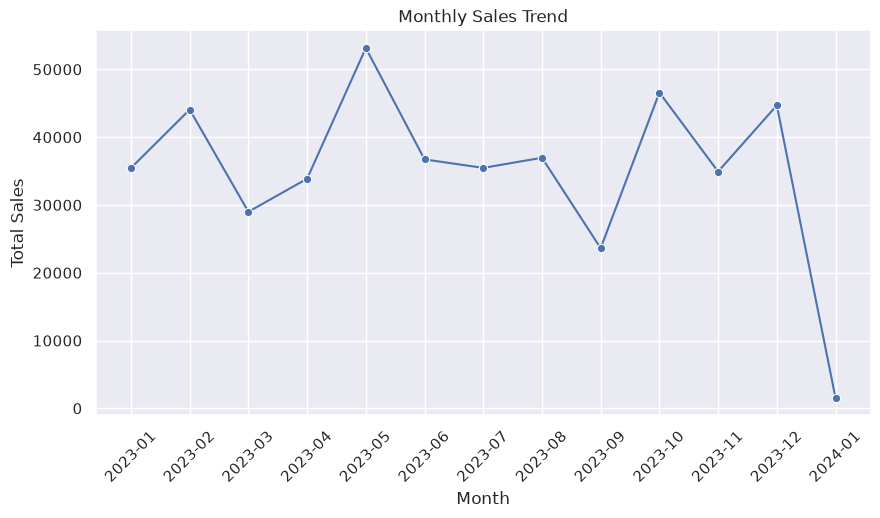

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df = pd.read_csv("/home/aman-vishwakarma/Documents/Ashwini/OIBSIP/retail_sales_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Total Amount"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()



# Monthly Sales Trend


# Code to create the line plot
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="Month", y="Total Amount", marker="o")
plt.title("Monthly Sales Trend")
plt.show()


### Observation
- Sales gradually increased from January to March.
- The highest sales were recorded in July.
- Sales declined slightly towards the end of the year.

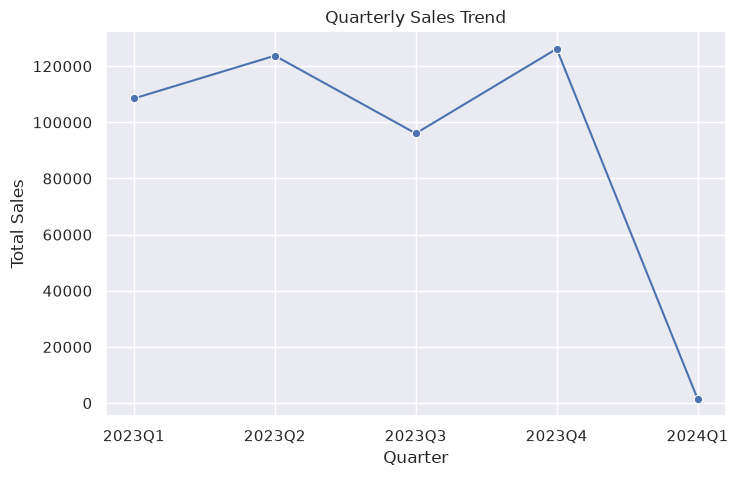

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=quarterly_sales,
    x="Quarter",
    y="Total Amount",
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

# Quarterly Sales Trend

# Code to create the line plot
sns.lineplot(data=quarterly_sales,x="Quarter",y="Total Amount",marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

### Observation
The quarterly trend summarizes sales over each three-month period, making it easier to identify broader seasonal patterns and compare business performance across quarters.

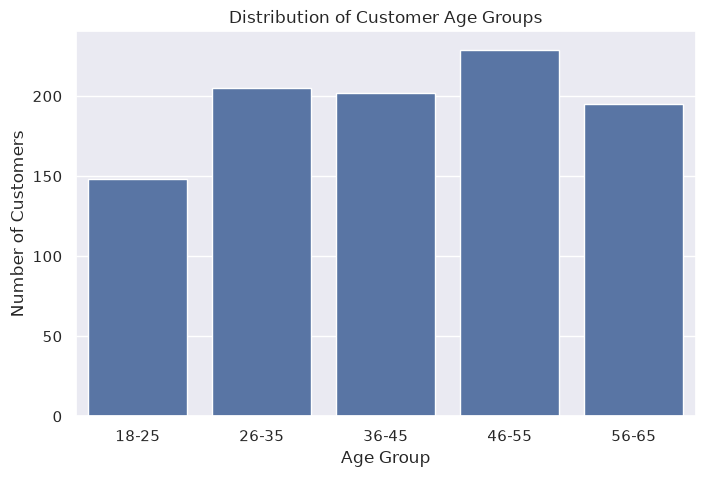

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Age Group")

plt.title("Distribution of Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Most customers belong to the 26–35 age group.
- The fewest customers are in the 56–65 age group.
- The business mainly attracts young and middle-aged customers.

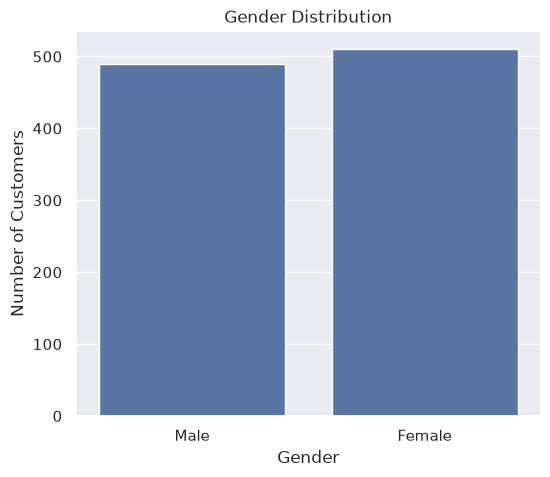

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Male customers slightly outnumber female customers.
- The customer base is fairly balanced between genders.

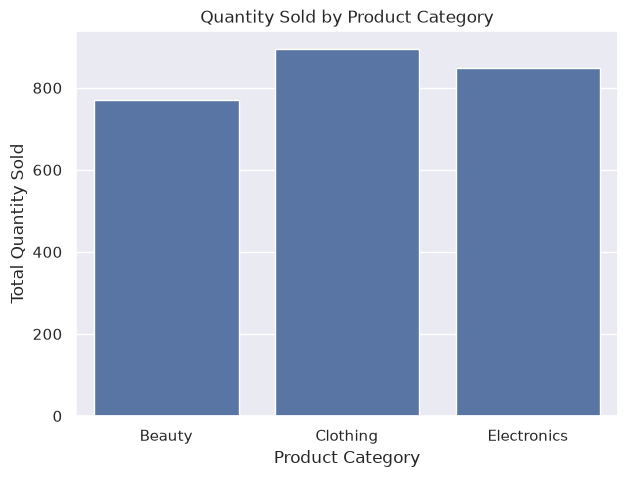

In [54]:
product_quantity = df.groupby("Product Category")["Quantity"].sum().reset_index()

product_quantity

plt.figure(figsize=(7,5))

sns.barplot(
    data=product_quantity,
    x="Product Category",
    y="Quantity"
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.show()

### Observation

- Clothing has the highest quantity sold.
- Electronics follows closely.
- Beauty products have comparatively lower sales volume.

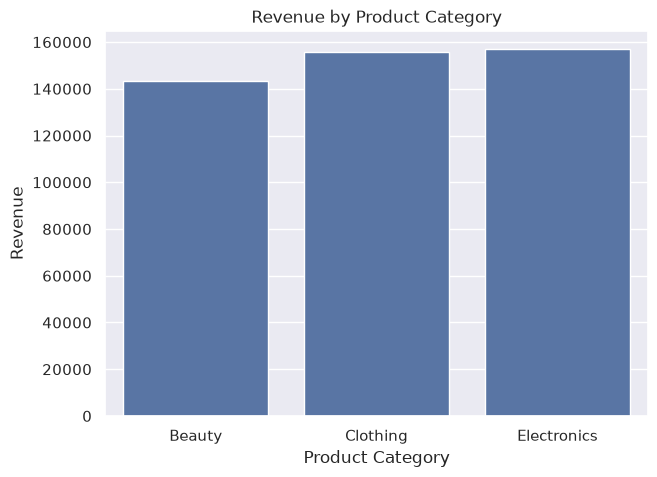

In [55]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=category_sales,
    x="Product Category",
    y="Total Amount"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

### Observation

- Electronics generates the highest revenue.
- Clothing is the second-highest revenue contributor.
- Beauty products contribute the least revenue.

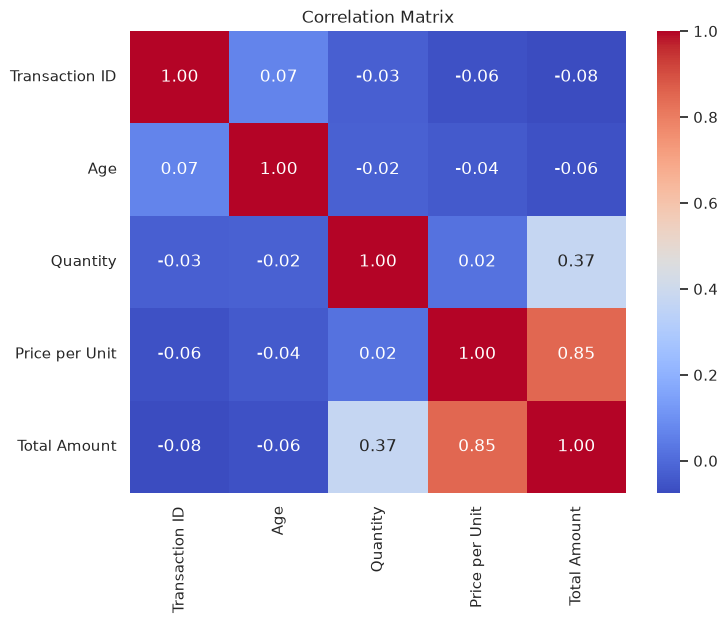

In [56]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

- Total Amount has a strong positive correlation with Quantity.
- Price per Unit also positively affects Total Amount.
- Age has little correlation with sales-related variables.

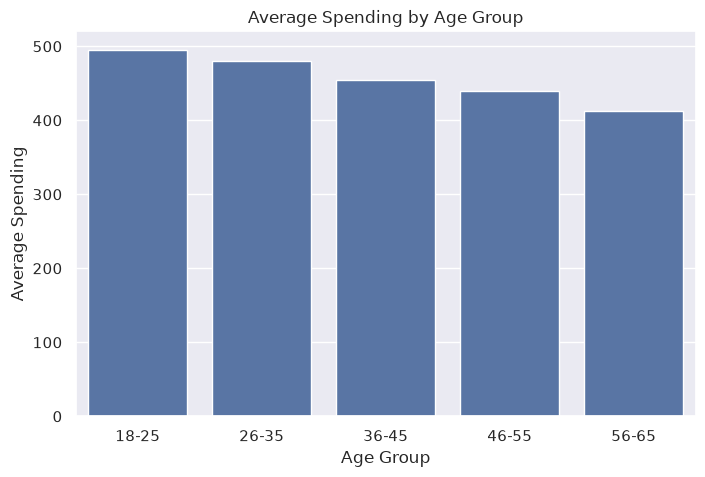

In [57]:
age_spending = df.groupby("Age Group")["Total Amount"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_spending,
    x="Age Group",
    y="Total Amount"
)

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")

plt.show()

### Observation

- Customers aged 36–45 have the highest average spending.
- Younger customers make more purchases but spend less per transaction.
- Middle-aged customers contribute higher-value purchases.

# Conclusion

## Business Recommendations

1. Increase inventory and marketing for the product category that generates the highest revenue to maximize profits.

2. Design targeted promotional campaigns for the highest-spending age group to encourage repeat purchases.

3. Improve sales of lower-performing product categories through discounts, product bundles, or seasonal offers.

4. Continue engaging both male and female customers with balanced marketing strategies, as the customer base is relatively even.

5. Monitor monthly and quarterly sales trends to prepare inventory and staffing during peak sales periods.